# Week12 - PySparkPy QUICK shortcut for Data Scientics


# ADV Python for DS
Revised from Beata Faron

---


**Goal:**
summarizes the most common PySpark operations for:

* Data loading and schema
* EDA (nulls, schema, describe)
* Feature engineering (lag, rolling)
* Modeling (regression)
* Evaluation
* Utilities for VectorAssembler, Pipeline, and Window
* Accelerate PySpark ML projects

**Dataset**
Fast-Moving Consumer Goods (FMCG) sector between 2022 and 2024.

This dataset simulates daily-level transactional data for products sold in the Fast-Moving Consumer Goods (FMCG) sector between 2022 and 2024.

It is designed to support analysis of:

* Seasonality and product lifecycle
* Promotion and holiday effects
* Stockouts and inventory dynamics
* Demand forecasting and feature engineering



# **1) Check out the data**

**Import Libraries**

In [1]:
# Install PySpark (only once per session)
!pip install -q pyspark

In [3]:
# Silence PySpark logging
import logging
logger = logging.getLogger('py4j')
logger.setLevel(logging.ERROR)


In [4]:
# Initialize SparkSession
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("PySpark Kaggle") \
    .getOrCreate()

spark

In [5]:
#Import pyspark libraries
from pyspark.sql.functions import col, when, count, lag, avg, stddev
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql import functions as F
from pyspark.sql.window import Window

In [8]:
#Import non-pyspark libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

**Check out the Data**

In [6]:
from google.colab import files
uploaded = files.upload()

Saving FMCG_2022_2024.csv to FMCG_2022_2024.csv


In [7]:
import io
#df = pd.read_csv(io.BytesIO(uploaded['FMCG_2022_2024.csv']))
df = spark.read.csv('FMCG_2022_2024.csv', header=True, inferSchema=True)
df

DataFrame[date: date, sku: string, brand: string, segment: string, category: string, channel: string, region: string, pack_type: string, price_unit: double, promotion_flag: int, delivery_days: int, stock_available: int, delivered_qty: int, units_sold: int]

In [9]:
df = df[df["sku"] == "MI-006"]

In [10]:
#shape of data
df.count()

8221

In [11]:
# Display the first 5 rows
print(df.head())

Row(date=datetime.date(2022, 1, 21), sku='MI-006', brand='MiBrand1', segment='Milk-Seg3', category='Milk', channel='Retail', region='PL-Central', pack_type='Multipack', price_unit=2.38, promotion_flag=0, delivery_days=1, stock_available=141, delivered_qty=128, units_sold=9)


In [12]:
#show schema and tables relations
df.printSchema()


root
 |-- date: date (nullable = true)
 |-- sku: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- segment: string (nullable = true)
 |-- category: string (nullable = true)
 |-- channel: string (nullable = true)
 |-- region: string (nullable = true)
 |-- pack_type: string (nullable = true)
 |-- price_unit: double (nullable = true)
 |-- promotion_flag: integer (nullable = true)
 |-- delivery_days: integer (nullable = true)
 |-- stock_available: integer (nullable = true)
 |-- delivered_qty: integer (nullable = true)
 |-- units_sold: integer (nullable = true)



In [13]:
# Display 'description' of the data in the DataFrame
df.describe()

DataFrame[summary: string, sku: string, brand: string, segment: string, category: string, channel: string, region: string, pack_type: string, price_unit: string, promotion_flag: string, delivery_days: string, stock_available: string, delivered_qty: string, units_sold: string]

In [14]:
#name  of columns
df.columns

['date',
 'sku',
 'brand',
 'segment',
 'category',
 'channel',
 'region',
 'pack_type',
 'price_unit',
 'promotion_flag',
 'delivery_days',
 'stock_available',
 'delivered_qty',
 'units_sold']

In [27]:
df.count()

8221

# **2) Exploratory data analysis (EDA)**

In [15]:
df.limit(5).toPandas()


,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
0,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-Central,Multipack,2.38,0,1,141,128,9
1,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-North,Single,1.55,1,3,0,129,0
2,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-South,Carton,4.00,0,5,118,161,8
3,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-Central,Single,5.16,0,2,81,114,7
4,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-North,Single,7.66,0,4,148,204,12


In [16]:
df.describe().toPandas()


,summary,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
0,count,8221,8221,8221,8221,8221,8221,8221,8221,8221,8221,8221,8221,8221
1,mean,None,None,None,None,None,None,None,5.240336941977871,0.14499452621335604,3.0017029558447876,158.05121031504683,179.48400437902933,16.132222357377447
2,stddev,None,None,None,None,None,None,None,2.1667277223290715,0.35211673522499365,1.4287615721323874,53.01702595787665,40.1142546254775,9.302638575394607
3,min,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-Central,Carton,1.5,0,1,0,2,0
4,max,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-South,Single,9.0,1,5,352,330,94


In [17]:
# Null count
nulls = df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).toPandas()
nulls

,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# 3) Feature Engineering

In [28]:
# Feature Engineering – Lag & Rolling
df = df.withColumn("week", F.date_trunc("week", "date"))
df = df.withColumn("week_number", F.weekofyear("date"))
df = df.withColumn("month", F.month("date"))
df = df.withColumn("year", F.year("date"))

In [29]:
df.limit(3).toPandas()


,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold,week,week_number,month,year
0,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-Central,Multipack,2.38,0,1,141,128,9,2022-01-17,3,1,2022
1,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-North,Single,1.55,1,3,0,129,0,2022-01-17,3,1,2022
2,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-South,Carton,4.00,0,5,118,161,8,2022-01-17,3,1,2022


Add your Description Here
-
-
-

# 4) Time Split and Modeling

In [39]:
# Train/test split (time-aware)
unique_dates = df.select("date").distinct().orderBy("date")
cutoff = unique_dates.limit(int(unique_dates.count() * 0.8)).orderBy("date", ascending=False).first()["date"]
train_df = df.filter(col("date") <= cutoff)
test_df = df.filter(col("date") > cutoff)

print(f"Time-aware split at: {cutoff} → Train: {train_df.count()} rows, Test: {test_df.count()} rows")

Time-aware split at: 2024-05-29 → Train: 6587 rows, Test: 1634 rows


In [20]:
df.printSchema()


root
 |-- date: date (nullable = true)
 |-- sku: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- segment: string (nullable = true)
 |-- category: string (nullable = true)
 |-- channel: string (nullable = true)
 |-- region: string (nullable = true)
 |-- pack_type: string (nullable = true)
 |-- price_unit: double (nullable = true)
 |-- promotion_flag: integer (nullable = true)
 |-- delivery_days: integer (nullable = true)
 |-- stock_available: integer (nullable = true)
 |-- delivered_qty: integer (nullable = true)
 |-- units_sold: integer (nullable = true)



In [31]:
# Regression Modeling
features = ["price_unit", "promotion_flag","delivery_days", "stock_available", "delivered_qty","week_number", "month", "year"]
assembler = VectorAssembler(inputCols=features, outputCol="features")
regressor = RandomForestRegressor(labelCol="units_sold", featuresCol="features")
pipeline = Pipeline(stages=[assembler, regressor])
model = pipeline.fit(train_df)

Add your Description Here
-
-
-

# 5) Model Evaluation

Let's evaluate the model by checking out it's coefficients and how we can interpret them.

In [32]:
preds = model.transform(test_df)


In [40]:
rmse = RegressionEvaluator(labelCol="units_sold", predictionCol="prediction", metricName="rmse").evaluate(preds)
mae = RegressionEvaluator(labelCol="units_sold", predictionCol="prediction", metricName="mae").evaluate(preds)

Add your Description Here
-
-
-

In [43]:
print(f"RMSE: {rmse:.2f}\nMAE:  {mae:.2f}")

RMSE: 4.44
MAE:  3.11


In [44]:
import pandas as pd
import matplotlib.pyplot as plt

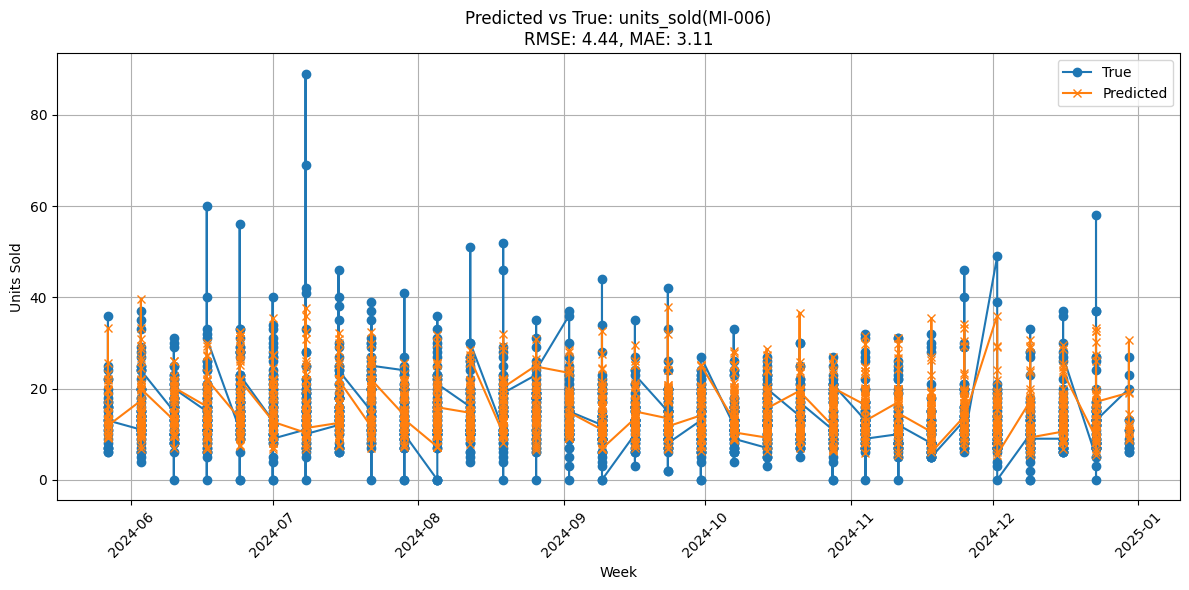

In [45]:
pdf = preds.toPandas()

pdf = pdf.sort_values("week")

plt.figure(figsize=(12, 6))
plt.plot(pdf["week"], pdf["units_sold"], label="True", marker='o')
plt.plot(pdf["week"], pdf["prediction"], label="Predicted", marker='x')
plt.title(f"Predicted vs True: units_sold(MI-006)\nRMSE: {rmse:.2f}, MAE: {mae:.2f}")
plt.xlabel("Week")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Add your Description Here
-
-
-

**Interpreting the results:**

The RMSE (Root Mean Squared Error) of 4.60 and MAE (Mean Absolute Error) of 3.27 are metrics that tell us how well the model's predictions match the actual values.



This notebook demonstrates a workflow for analyzing and modeling sales data for a specific product (MI-006) using PySpark.

Here's a brief summary:

* Setup: The notebook starts by setting up the PySpark environment and importing necessary libraries.
* Data Loading and Exploration: The dataset is loaded, and initial checks are performed to understand the data's structure, schema, and to identify any missing values. The data is then filtered to focus on a single product (MI-006).
* Feature Engineering: New time-based features (week, week number, month, year) are created from the date column to capture potential temporal patterns.
* Time-Aware Split and Modeling: The data is split into training and testing sets based on time to simulate a real-world forecasting scenario. A Random Forest Regressor model is built using a pipeline to predict units_sold based on selected features.
* Model Evaluation: The trained model's performance is evaluated using RMSE and MAE metrics, and the predictions are visualized against the actual values to assess the model's accuracy over time. Feature importances are also extracted to understand which features were most influential in the model's predictions.

In essence, the notebook takes raw sales data, prepares it for modeling, trains a predictive model, and evaluates its performance to understand how well it can forecast units sold for a specific product.